<a href="https://colab.research.google.com/github/abigailLee530/mnist_digit_classifier/blob/main/trainingModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import Dependencies

import torch
import torchvision

from torch import nn, optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train = datasets.MNIST(root = 'data',
                       train = True,
                       download = True,
                       transform = transform )

test = datasets.MNIST(root = 'data',
                       train = True,
                       download = True,
                       transform = transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.60MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


In [3]:
train_dataloader = DataLoader(dataset = train,
                              batch_size = 32,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test,
                              batch_size = 32,
                              shuffle = False)

In [4]:
import random
import matplotlib.pyplot as plt


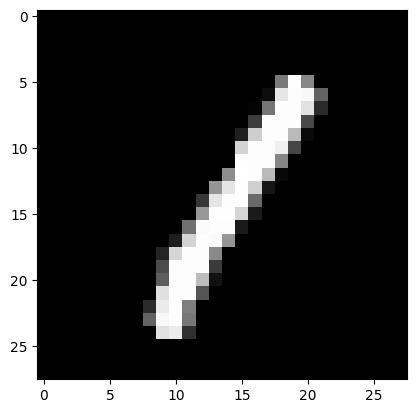

In [5]:
plt.imshow(train[random.randint(0, 100)][0].squeeze(), cmap = 'grey')

In [6]:
class Net(nn.Module):
  def __init__(self, fc_input_features):
    super().__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size = (3,3)),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size = (2,2)),

        nn.Conv2d(in_channels=16, out_channels=8, kernel_size = (3,3)),
        nn.ReLU()
    )

    self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=fc_input_features, out_features=10)
    )

  def forward(self, x):
    return self.fc(self.conv(x))

In [7]:
model = Net(fc_input_features=968)

In [8]:
model(torch.rand(1,1,28,28))

tensor([[ 0.0178,  0.0637, -0.0636, -0.0640,  0.0315, -0.1227,  0.0475,  0.0667,
          0.0492,  0.0599]], grad_fn=<AddmmBackward0>)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
model = Net(fc_input_features=968).to(device)

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [12]:
epochs = 5
for epoch in range(epochs):
  train_loss, test_loss = 0,0

  for batch, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)

    y_hat = model(X)

    loss = loss_fn(y_hat, y)

    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(train_dataloader)

  print(f"Train loss: {train_loss: .3f}")

  with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
      X, y = X.to(device), y.to(device)

      y_hat = model(X)

      loss = loss_fn(y_hat, y)

      test_loss += loss.item()

    test_loss/=len(test_dataloader)

print(f"Test Lost: {test_loss: .3f}")

Train loss:  0.245
Train loss:  0.090
Train loss:  0.067
Train loss:  0.056
Train loss:  0.049
Test Lost:  0.039


In [13]:
random_image = random.choice(test)

In [19]:
random_image_tensor = random_image[0].to(device)
random_image_label = random_image[1]
random_image_tensor.shape

torch.Size([1, 28, 28])

In [24]:
torch.softmax(model(random_image_tensor.unsqueeze(dim = 0)), dim=1).argmax()

tensor(2, device='cuda:0')

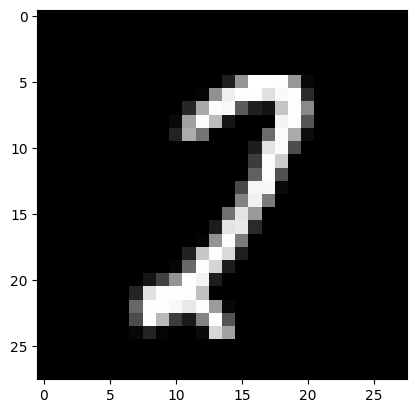

In [25]:
plt.imshow(random_image_tensor.squeeze().cpu(), cmap = 'grey')